<h1>Module 1: Introduction</h1>

In [1]:
# 📚 Introduction
# In this project, we explore and clean a USA salary dataset.
# Objectives:
# - Data inspection and cleaning
# - Feature engineering
# - Data visualization
# - Export cleaned data

<h1>Module 2: Data Loading</h1>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Set Seaborn style
sns.set(style='whitegrid')

# Load the dataset
df = pd.read_csv("C:/Users/Amar Khaggah/Downloads/data science notes/notebooks/Salaries.csv")
df.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


<h1>Module 3: Data Overview</h1>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  object 
 2   JobTitle          148654 non-null  object 
 3   BasePay           148045 non-null  float64
 4   OvertimePay       148650 non-null  float64
 5   OtherPay          148650 non-null  float64
 6   Benefits          112491 non-null  float64
 7   TotalPay          148654 non-null  float64
 8   TotalPayBenefits  148654 non-null  float64
 9   Year              148654 non-null  int64  
 10  Notes             0 non-null       float64
 11  Agency            148654 non-null  object 
 12  Status            0 non-null       float64
dtypes: float64(8), int64(2), object(3)
memory usage: 14.7+ MB


In [10]:
df.describe()

,Id,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Status
count,148654.000000,148045.000000,148650.000000,148650.000000,112491.000000,148654.000000,148654.000000,148654.000000,0.0,0.0
mean,74327.500000,66325.448840,5066.059886,3648.767297,25007.893151,74768.321972,93692.554811,2012.522643,NaN,NaN
std,42912.857795,42764.635495,11454.380559,8056.601866,15402.215858,50517.005274,62793.533483,1.117538,NaN,NaN
min,1.000000,-166.010000,-0.010000,-7058.590000,-33.890000,-618.130000,-618.130000,2011.000000,NaN,NaN
25%,37164.250000,33588.200000,0.000000,0.000000,11535.395000,36168.995000,44065.650000,2012.000000,NaN,NaN
50%,74327.500000,65007.450000,0.000000,811.270000,28628.620000,71426.610000,92404.090000,2013.000000,NaN,NaN
75%,111490.750000,94691.050000,4658.175000,4236.065000,35566.855000,105839.135000,132876.450000,2014.000000,NaN,NaN
max,148654.000000,319275.010000,245131.880000,400184.250000,96570.660000,567595.430000,567595.430000,2014.000000,NaN,NaN


In [11]:
df.isnull().sum()

Id                       0
EmployeeName             0
JobTitle                 0
BasePay                609
OvertimePay              4
OtherPay                 4
Benefits             36163
TotalPay                 0
TotalPayBenefits         0
Year                     0
Notes               148654
Agency                   0
Status              148654
dtype: int64

In [12]:
print("\nTop Job Titles:\n", df['JobTitle'].value_counts().head())
print("\nTop Agencies:\n", df['Agency'].value_counts().head())


Top Job Titles:
 JobTitle
Transit Operator                7036
Special Nurse                   4389
Registered Nurse                3736
Public Svc Aide-Public Works    2518
Police Officer 3                2421
Name: count, dtype: int64

Top Agencies:
 Agency
San Francisco    148654
Name: count, dtype: int64


<h1>Module 4: Data Cleaning</h1>

In [14]:
# Drop unnecessary columns with no data
df_cleaned = df.drop(columns=['Notes', 'Status'])

# Fill missing values in other columns
df_cleaned['BasePay'].fillna(df_cleaned['BasePay'].median(), inplace=True)
df_cleaned['OvertimePay'].fillna(df_cleaned['OvertimePay'].median(), inplace=True)
df_cleaned['OtherPay'].fillna(df_cleaned['OtherPay'].median(), inplace=True)
df_cleaned['Benefits'].fillna(df_cleaned['Benefits'].median(), inplace=True)

# Remove any duplicate rows
df_cleaned = df_cleaned.drop_duplicates()

# Confirm the cleaning steps
print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", df_cleaned.shape)

# Check missing values after cleaning
print(df_cleaned.isnull().sum())


C:\Users\Amar Khaggah\AppData\Local\Temp\ipykernel_8880\61643178.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['BasePay'].fillna(df_cleaned['BasePay'].median(), inplace=True)
C:\Users\Amar Khaggah\AppData\Local\Temp\ipykernel_8880\61643178.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

Shape before cleaning: (148654, 13)
Shape after cleaning: (148654, 11)
Id                  0
EmployeeName        0
JobTitle            0
BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
Year                0
Agency              0
dtype: int64


<h1>Module 5: Feature Engineering</h1>

In [15]:
# Label Encode all object-type columns
label_encoders = {}

for col in df_cleaned.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_cleaned[col + '_Encoded'] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

print("Encoded columns:", list(label_encoders.keys()))

Encoded columns: ['EmployeeName', 'JobTitle', 'Agency']


<h1>Module 6: Export Cleaned Dataset</h1>

In [17]:
df_cleaned.to_csv('cleaned_dataset.csv', index=False)
print("Cleaned dataset saved as 'cleaned_dataset.csv'")

Cleaned dataset saved as 'cleaned_dataset.csv'


<h1>Module 7:Visualization – Before Cleaning</h1>

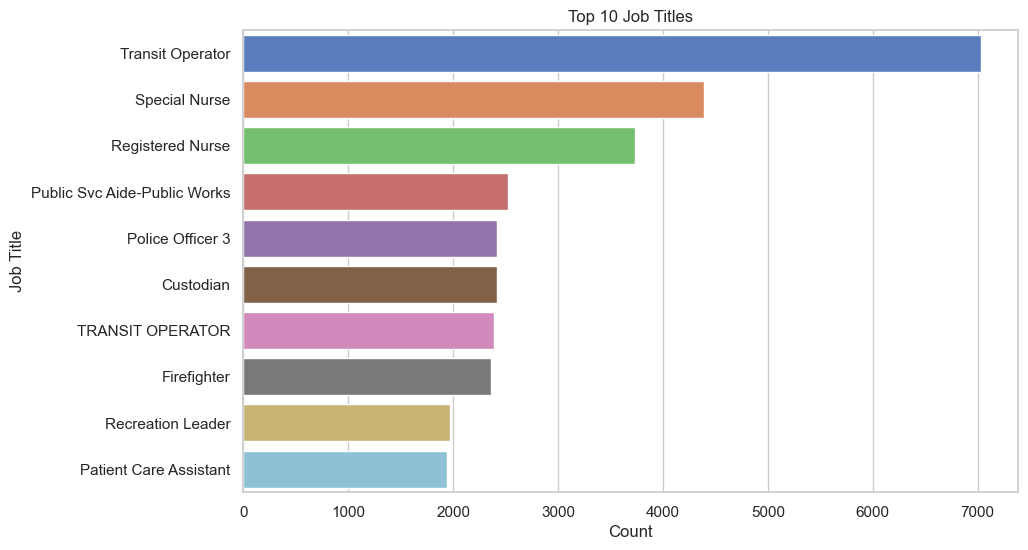

In [19]:
# Job title frequency
plt.figure(figsize=(10,6))
top_jobs = df['JobTitle'].value_counts().head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='muted')
plt.title('Top 10 Job Titles')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.show()

C:\Users\Amar Khaggah\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


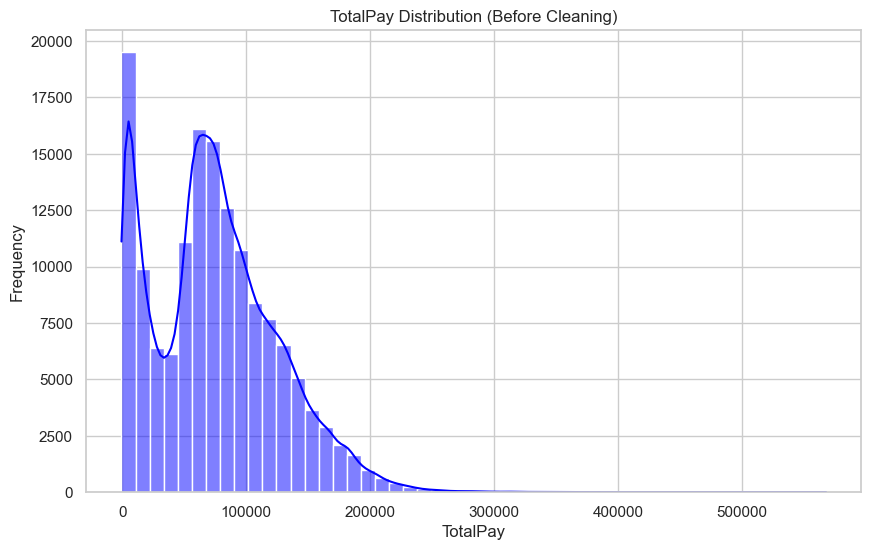

In [20]:
# TotalPay distribution
plt.figure(figsize=(10,6))
sns.histplot(df['TotalPay'], bins=50, kde=True, color='blue')
plt.title('TotalPay Distribution (Before Cleaning)')
plt.xlabel('TotalPay')
plt.ylabel('Frequency')
plt.show()

<h1>Module 8: Visualization – After Cleaning</h1>

C:\Users\Amar Khaggah\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


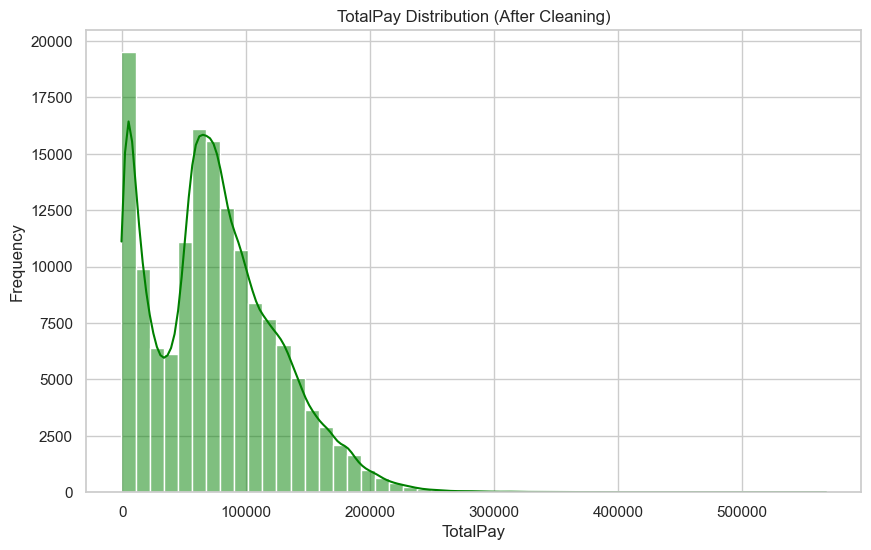

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(df_cleaned['TotalPay'], bins=50, kde=True, color='green')
plt.title('TotalPay Distribution (After Cleaning)')
plt.xlabel('TotalPay')
plt.ylabel('Frequency')
plt.show()


C:\Users\Amar Khaggah\anaconda\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


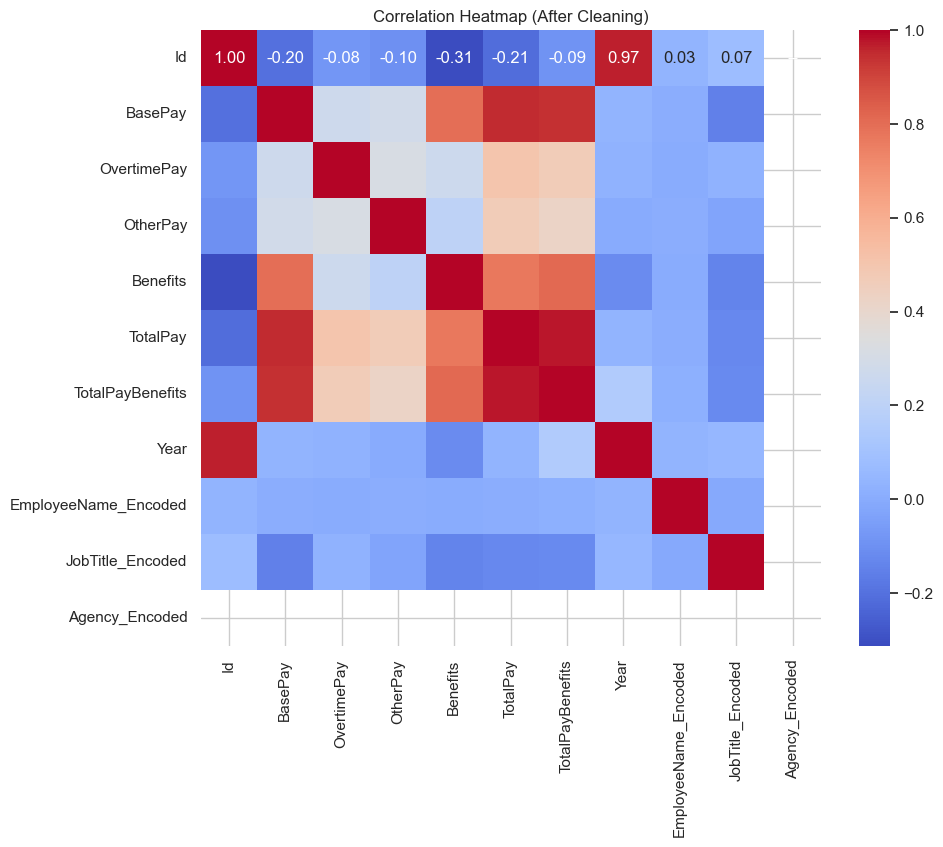

In [24]:
# Correlation heatmap after cleaning
plt.figure(figsize=(10,8))
corr_after = df_cleaned.corr(numeric_only=True)
sns.heatmap(corr_after, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (After Cleaning)')
plt.show()